#1.State the hypothesis

In [1]:
import numpy as np
import scipy.stats as stats

# Example data
groupA = [20000, 15000, 10000, 25000, 30000]
groupB = [22000, 16000, 18000, 21000, 27000]

# Calculate means
mean_A = np.mean(groupA)
mean_B = np.mean(groupB)

# State hypotheses
null_hypothesis = "The mean sales amounts of group A and group B are equal."
alternative_hypothesis = "The mean sales amounts of group A and group B are not equal."

# Perform t-test
t_stat, p_value = stats.ttest_ind(groupA, groupB)

print(f"Null Hypothesis (H0): {null_hypothesis}")
print(f"Alternative Hypothesis (H1): {alternative_hypothesis}")
print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value}")

# Conclusion based on p-value
alpha = 0.05  # significance level
if p_value < alpha:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

#Hypothesis Definition:
#A hypothesis is a testable statement or prediction about the relationship between two or more variables. In the context of scientific research and statistical analysis, it serves as a foundation for experiments and data analysis.
#Chisquare test Definition:
#Chi-square testing is a statistical method used to determine whether there is a significant association between two categorical variables. It compares the observed frequencies of events or characteristics in a sample to the expected frequencies based on a specific hypothesis.



Null Hypothesis (H0): The mean sales amounts of group A and group B are equal.
Alternative Hypothesis (H1): The mean sales amounts of group A and group B are not equal.
t-statistic: -0.19975046777556893
p-value: 0.8466597012445398
Fail to reject the null hypothesis.


#2.Compute the Chi-Square Statistic


In [2]:
import numpy as np

def chi_square_statistic(observed, expected):
    """
    Calculate the Chi-Square statistic.

    Parameters:
        observed (list or numpy array): Observed frequencies.
        expected (list or numpy array): Expected frequencies.

    Returns:
        float: Chi-Square statistic.
    """
    observed = np.array(observed)
    expected = np.array(expected)

    if len(observed) != len(expected):
        raise ValueError("Observed and Expected frequencies must have the same length.")

    chi_square = np.sum((observed - expected) ** 2 / expected)
    return chi_square

# Example usage
observed = [50, 30, 20]
expected = [40, 40, 20]

chi_square = chi_square_statistic(observed, expected)
print(f"Chi-Square Statistic: {chi_square}")

#Explanation:
#1.Input Validation:Ensures that the observed and expected arrays have the same length.
#2.Calculation:
#Computes the squared differences between observed and expected values.
#Divides by the expected value for each category.
#Sums the results to get the Chi-Square statistic.




Chi-Square Statistic: 5.0


#3. Determine the Critical Value

In [3]:
from scipy.stats import chi2

def critical_value(alpha, num_categories):
    """
    Calculate the critical value for a Chi-Square test.

    Parameters:
        alpha (float): Significance level (e.g., 0.05 for a 95% confidence level).
        num_categories (int): Number of categories.

    Returns:
        float: Critical value.
    """
    degrees_of_freedom = num_categories - 1
    return chi2.ppf(1 - alpha, degrees_of_freedom)

# Example usage
alpha = 0.05
num_categories = 3  # For observed frequencies in 3 categories

critical_val = critical_value(alpha, num_categories)
print(f"Critical Value at alpha={alpha} with {num_categories - 1} degrees of freedom: {critical_val}")

#Explanation:
#1.Degrees of Freedom (df):
#df=Number of Categories−1
#For 𝑛=3n=3, 𝑑𝑓=3−1=2

#2.Chi-Square Distribution:
#The chi2.ppf function from scipy.stats computes the percentile point function (inverse CDF) for the Chi-Square distribution.
#1−α gives the cumulative probability for the critical value.

#3.Critical Value: The value is determined based on the degrees of freedom and significance level.

Critical Value at alpha=0.05 with 2 degrees of freedom: 5.991464547107979


#4.Make Decision

Chi-Square Statistic: 5.0
Critical Value at alpha=0.05: 5.991464547107979
Decision: Fail to reject the null hypothesis (H0).


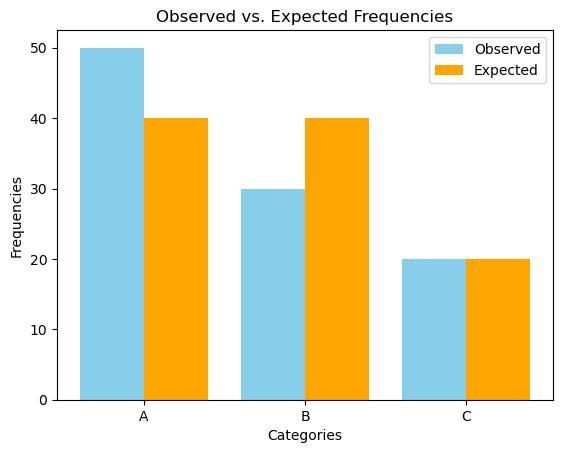

In [4]:
import numpy as np
from scipy.stats import chi2
import matplotlib.pyplot as plt

def chi_square_statistic(observed, expected):
    """
    Calculate the Chi-Square statistic.

    Parameters:
        observed (list or numpy array): Observed frequencies.
        expected (list or numpy array): Expected frequencies.

    Returns:
        float: Chi-Square statistic.
    """
    observed = np.array(observed)
    expected = np.array(expected)

    if len(observed) != len(expected):
        raise ValueError("Observed and Expected frequencies must have the same length.")

    chi_square = np.sum((observed - expected) ** 2 / expected)
    return chi_square

def critical_value(alpha, num_categories):
    """
    Calculate the critical value for a Chi-Square test.

    Parameters:
        alpha (float): Significance level (e.g., 0.05 for a 95% confidence level).
        num_categories (int): Number of categories.

    Returns:
        float: Critical value.
    """
    degrees_of_freedom = num_categories - 1
    return chi2.ppf(1 - alpha, degrees_of_freedom)

def make_decision(chi_square, critical_val):
    """
    Make a decision to reject or not reject the null hypothesis.

    Parameters:
        chi_square (float): Chi-Square statistic.
        critical_val (float): Critical value.

    Returns:
        str: Decision result.
    """
    if chi_square > critical_val:
        return "Reject the null hypothesis (H0)."
    else:
        return "Fail to reject the null hypothesis (H0)."

# Input data
observed = [50, 30, 20]
expected = [40, 40, 20]
alpha = 0.05
num_categories = len(observed)

# Calculate Chi-Square statistic
chi_square = chi_square_statistic(observed, expected)

# Calculate critical value
critical_val = critical_value(alpha, num_categories)

# Make the decision
decision = make_decision(chi_square, critical_val)

# Output results
print(f"Chi-Square Statistic: {chi_square}")
print(f"Critical Value at alpha={alpha}: {critical_val}")
print(f"Decision: {decision}")

# Optional: Plot observed vs expected frequencies
def plot_frequencies(observed, expected, categories=None):
    x = np.arange(len(observed))  # Category indices
    width = 0.4                  # Width of the bars

    plt.bar(x - width/2, observed, width, label='Observed', color='skyblue')
    plt.bar(x + width/2, expected, width, label='Expected', color='orange')

    plt.xlabel('Categories')
    plt.ylabel('Frequencies')
    plt.title('Observed vs. Expected Frequencies')
    if categories:
        plt.xticks(x, categories)
    else:
        plt.xticks(x, [f"Category {i+1}" for i in x])

    plt.legend()
    plt.show()

categories = ['A', 'B', 'C']
plot_frequencies(observed, expected, categories)

#Explanation:
#1.If the Chi-Square value is larger than the critical value:
#The observed data is significantly different from what we expected, and we reject the null hypothesis (the assumption that there’s no real difference).
#2.If the Chi-Square value is smaller or equal to the critical value:The observed data is not significantly different, and we fail to reject the null hypothesis.